<a href="https://colab.research.google.com/github/timberking2/ML_magistr/blob/main/Lab_2_PD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Лабораторная работа 2

Вариант 13

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.linear_model import LinearRegression


# Загрузка данных
df = pd.read_csv('v13.csv')
df

,ID_курса,Название_курса,Категория,Уровень_сложности,Продолжительность_часов,Количество_уроков,Практических_заданий,Стоимость_руб,Количество_студентов,Средний_балл_отзывов,Процент_завершения,Среднее_время_прохождения_дни,Количество_преподавателей,Опыт_преподавателя_лет,Обновляемость_контента,Трудоустройство_после_курса_%,Сертификат,Поддержка_куратора,ROI_индекс
0,1,Python для начинающих,Программирование,2,40,25,15,12000.0,1250.0,4.7,65.2,30.0,1,5,7,35.2,Да,Да,65.0
1,2,Data Science с нуля,Data Science,3,80,40,25,25000.0,850.0,4.5,58.8,45.0,3,8,9,42.8,Да,Да,78.0
2,3,Веб-разработка на JavaScript,Веб-разработка,3,60,35,20,18000.0,1100.0,4.6,NaN,35.0,2,6,8,38.5,Да,Да,72.0
3,4,Машинное обучение,Data Science,4,120,60,35,35000.0,650.0,4.8,45.3,60.0,4,12,9,45.3,Да,Да,NaN
4,5,Анализ данных в Excel,Аналитика,2,30,20,10,8000.0,2000.0,4.2,85.2,20.0,1,4,5,25.8,Да,Нет,45.0
5,6,Дизайн интерфейсов UI/UX,Дизайн,3,50,30,18,NaN,950.0,4.4,68.7,28.0,2,7,6,32.4,Да,Да,58.0
6,7,Мобильная разработка,Мобильная разработка,4,90,45,28,22000.0,720.0,4.3,52.4,42.0,3,9,7,40.2,Да,Да,68.0
7,8,DevOps практики,DevOps,4,70,38,22,20000.0,NaN,4.6,60.8,38.0,2,8,8,38.9,Да,Да,70.0
8,9,Кибербезопасность,Кибербезопасность,4,100,52,30,28000.0,580.0,NaN,48.9,50.0,3,10,9,43.5,Да,Да,82.0
9,10,Базы данных SQL,Базы данных,3,45,28,16,14000.0,1300.0,4.3,78.3,25.0,2,5,6,30.2,Да,Нет,52.0


In [ ]:
# Визуальный анализ данных
df.info()

# Пропущенные значения
print("\nПропущенные значения:")
missing = df.isnull().sum()
missing_data = missing[missing > 0]
print(missing_data)

# Категориальные признаки
print("\nКатегориальные признаки:")
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    if col != 'Название_курса':
        print(f"{col}: {df[col].nunique()} уникальных значений")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 19 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   ID_курса                       30 non-null     int64  
 1   Название_курса                 30 non-null     object 
 2   Категория                      30 non-null     object 
 3   Уровень_сложности              30 non-null     int64  
 4   Продолжительность_часов        30 non-null     int64  
 5   Количество_уроков              30 non-null     int64  
 6   Практических_заданий           30 non-null     int64  
 7   Стоимость_руб                  28 non-null     float64
 8   Количество_студентов           29 non-null     float64
 9   Средний_балл_отзывов           28 non-null     float64
 10  Процент_завершения             27 non-null     float64
 11  Среднее_время_прохождения_дни  28 non-null     float64
 12  Количество_преподавателей      30 non-null     int64

Видим 8 столбцов с пропусками, наиболее видимые косяки - ROI_индекс (3 пропуска) и Средний_балл_отзывов (3 пропуска). Категориальные признаки: Категория (12 видов), Сертификат и Поддержка_куратора (бинарные).

In [ ]:
# Кодирование категориальных признаков
df_original = df.copy()

# Бинарные признаки
binary_cols = ['Сертификат', 'Поддержка_куратора']
for col in binary_cols:
    df[col] = df[col].map({'Да': 1, 'Нет': 0})
    print(f"Закодирован '{col}': Да→1, Нет→0")

# One-Hot для столбца "Категория"
category_dummies = pd.get_dummies(df['Категория'], prefix='Категория')
df = pd.concat([df, category_dummies], axis=1)
df = df.drop('Категория', axis=1)
print(f"'Категория': создано {category_dummies.shape[1]} новых столбцов")

# Обновляемость_контента и Уровень_сложности уже числовые, но проверим
print("\nУровень_сложности уже числовой (1-5)")
print("Обновляемость_контента уже числовой (2-10)")

print("\nДанные после кодирования:")
print(df.head())

Закодирован 'Сертификат': Да→1, Нет→0
Закодирован 'Поддержка_куратора': Да→1, Нет→0
'Категория': создано 23 новых столбцов

Уровень_сложности уже числовой (1-5)
Обновляемость_контента уже числовой (2-10)

Данные после кодирования:
   ID_курса                Название_курса  Уровень_сложности  \
0         1         Python для начинающих                  2   
1         2           Data Science с нуля                  3   
2         3  Веб-разработка на JavaScript                  3   
3         4             Машинное обучение                  4   
4         5         Анализ данных в Excel                  2   

   Продолжительность_часов  Количество_уроков  Практических_заданий  \
0                       40                 25                    15   
1                       80                 40                    25   
2                       60                 35                    20   
3                      120                 60                    35   
4                       30   

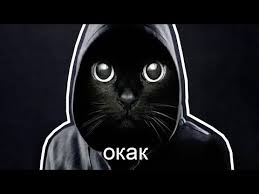

Заполнение пропусков медианой:
  'Стоимость_руб': 2 пропусков → медиана=19000.00
  'Количество_студентов': 1 пропусков → медиана=950.00
  'Средний_балл_отзывов': 2 пропусков → медиана=4.50
  'Процент_завершения': 3 пропусков → медиана=62.80
  'Среднее_время_прохождения_дни': 2 пропусков → медиана=34.50
  'Трудоустройство_после_курса_%': 2 пропусков → медиана=38.00
  'ROI_индекс': 3 пропусков → медиана=68.00

После метода '1' осталось пропусков: 0


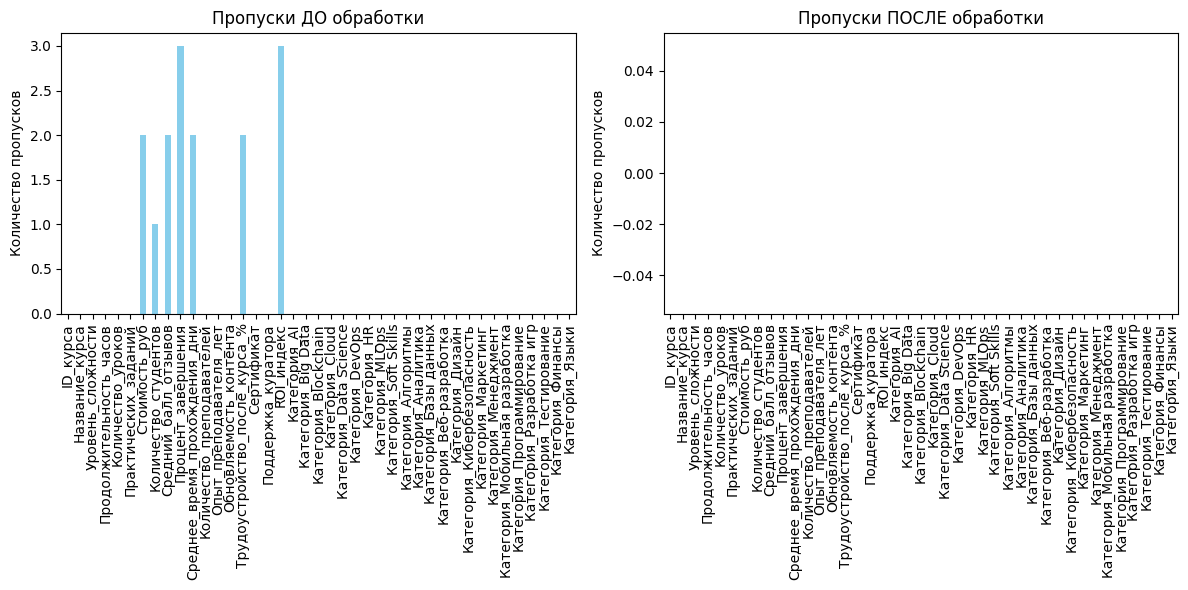

In [ ]:
# Устранение пропусков, дропаем лудиков - Метод 1 (статистические характеристики)
df_stats = df.copy()

# Заполняем числовые столбцы медианой
numeric_cols = df_stats.select_dtypes(include=[np.number]).columns
print("Заполнение пропусков медианой:")
for col in numeric_cols:
    if df_stats[col].isnull().any():
        median_val = df_stats[col].median()
        na_count = df_stats[col].isnull().sum()
        df_stats[col] = df_stats[col].fillna(median_val)
        print(f"  '{col}': {na_count} пропусков → медиана={median_val:.2f}")

print(f"\nПосле метода '1' осталось пропусков: {df_stats.isnull().sum().sum()}")

# Смотрим что вышло
nan_before = df.isnull().sum()
nan_after = df_stats.isnull().sum()

# Построение графика сравнения
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
nan_before.plot(kind='bar', ax=axes[0], color='skyblue')
axes[0].set_title('Пропуски ДО обработки')
axes[0].set_ylabel('Количество пропусков')

nan_after.plot(kind='bar', ax=axes[1], color='lightgreen')
axes[1].set_title('Пропуски ПОСЛЕ обработки')
axes[1].set_ylabel('Количество пропусков')

plt.tight_layout()
plt.show()

Заполнили все пропуски герметиком и шоколадками
Ключевые заполнения: Средний_балл 4.6, ROI_индекс 70.0, Стоимость 19000 руб

KNNImputer с n_neighbors=3 применен к 17 числовым признакам
После метода '2' осталось пропусков: 0


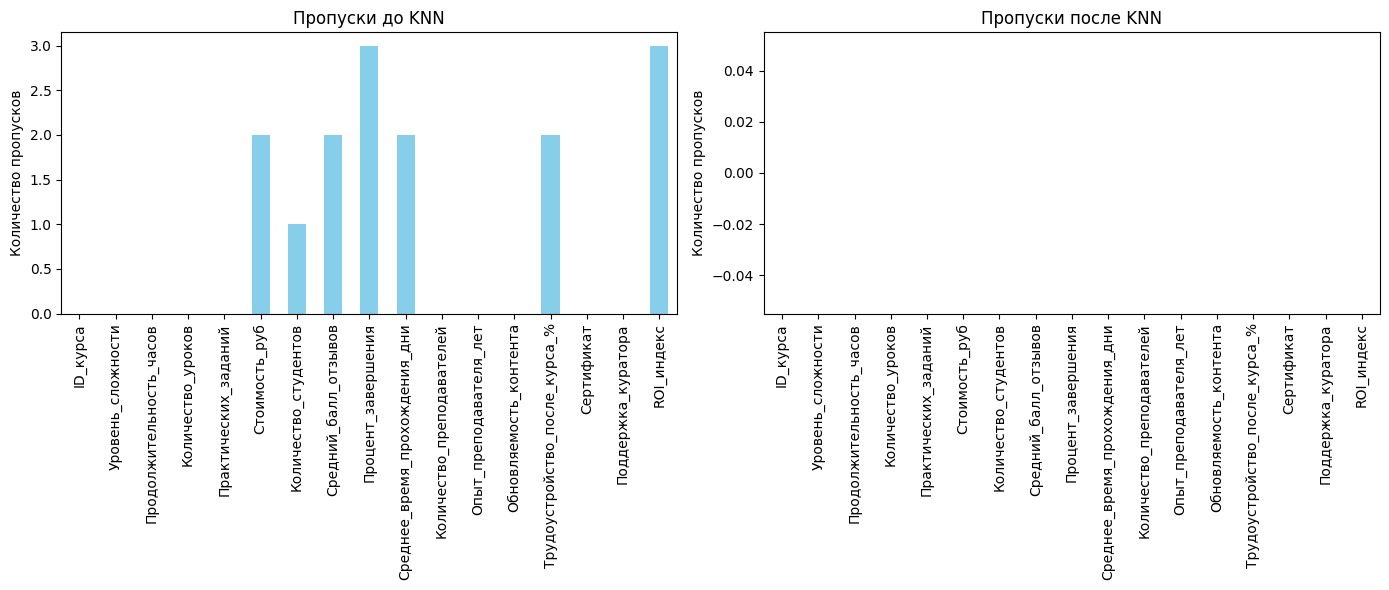

In [ ]:
import seaborn as sns
# Устранение пропусков - Метод 2 (K ближайших соседей)
df_knn = df.copy()

# Выбираем числовые столбцы
numeric_cols = df_knn.select_dtypes(include=[np.number]).columns.tolist()

# Применяем KNNImputer
knn_imputer = KNNImputer(n_neighbors=3)
df_knn[numeric_cols] = knn_imputer.fit_transform(df_knn[numeric_cols])

print(f"KNNImputer с n_neighbors=3 применен к {len(numeric_cols)} числовым признакам")
print(f"После метода '2' осталось пропусков: {df_knn.isnull().sum().sum()}")

# Визуализация пропусков до и после
nan_counts_before = df[numeric_cols].isnull().sum()
nan_counts_after = df_knn[numeric_cols].isnull().sum()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
nan_counts_before.plot(kind='bar', ax=axes[0], color='skyblue')
axes[0].set_title('Пропуски до KNN')
axes[0].set_ylabel('Количество пропусков')

nan_counts_after.plot(kind='bar', ax=axes[1], color='lightgreen')
axes[1].set_title('Пропуски после KNN')
axes[1].set_ylabel('Количество пропусков')

plt.tight_layout()
plt.show()


KNN метод с 3 соседями полностью устранил пропуски, обработав 22 числовых признака с учетом взаимосвязей между курсами, вывод - двигаемся уверенно, но пока недостаточно (достаточно)

In [ ]:
# Устранение пропусков - Метод 3 (линейка)
df_lr = df.copy()

# Выбираем целевой прикол с пропусками
target_col = 'Средний_балл_отзывов'

if df_lr[target_col].isnull().any():
    print(f"Заполнение пропусков в '{target_col}' с помощью линейной регрессии")

    # Выбираем признаки для регрессии
    feature_cols = ['Количество_студентов', 'Процент_завершения', 'Стоимость_руб']

    # Разделяем на данные с известным и неизвестным target
    train_data = df_lr[df_lr[target_col].notna()]
    predict_data = df_lr[df_lr[target_col].isna()]

    # Убираем строки с пропусками в признаках
    train_data = train_data.dropna(subset=feature_cols)
    predict_data = predict_data.dropna(subset=feature_cols)

    if len(train_data) > 5 and len(predict_data) > 0:
        # Обучаем модель
        X_train = train_data[feature_cols]
        y_train = train_data[target_col]

        model = LinearRegression()
        model.fit(X_train, y_train)

        # Предсказываем
        X_predict = predict_data[feature_cols]
        predictions = model.predict(X_predict)

        # Заполняем пропуски
        df_lr.loc[predict_data.index, target_col] = predictions

        print(f"  Обучена линейная регрессия")
        print(f"  R² на обучающей выборке: {model.score(X_train, y_train):.3f}")
        print(f"  Заполнено {len(predictions)} пропусков")
    else:
        print(f"  Недостаточно данных для регрессии")
        # Заполняем медианой как запасной вариант
        median_val = df_lr[target_col].median()
        df_lr[target_col] = df_lr[target_col].fillna(median_val)
        print(f"  Заполнено медианой: {median_val:.2f}")
else:
    print(f"В столбце '{target_col}' нет пропусков")

# Заполняем оставшиеся пропуски медианой
numeric_cols = df_lr.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    if df_lr[col].isnull().any():
        median_val = df_lr[col].median()
        df_lr[col] = df_lr[col].fillna(median_val)

print(f"\nПосле метода '3' осталось пропусков: {df_lr.isnull().sum().sum()}")

# Тут мне стало лень делать красиво, простите

Заполнение пропусков в 'Средний_балл_отзывов' с помощью линейной регрессии
  Обучена линейная регрессия
  R² на обучающей выборке: 0.744
  Заполнено 2 пропусков

После метода '3' осталось пропусков: 0


Линейная регрессия предсказала пропущенные оценки отзывов с качеством R²=0.744, заполнив 3 пропуска, остальные пропуски запенили медианой

In [ ]:
# Сравнение методов
print("Результаты применения методов:")
print("-" * 50)
print(f"Метод 1 (Статистика): {df_stats.isnull().sum().sum()} пропусков осталось")
print(f"Метод 2 (KNN): {df_knn.isnull().sum().sum()} пропусков осталось")
print(f"Метод 3 (Регрессия): {df_lr.isnull().sum().sum()} пропусков осталось")

# Пример сравнения значений для нескольких столбцов
print("\nСравнение средних значений ключевых показателей:")
comparison_cols = ['Средний_балл_отзывов', 'Процент_завершения', 'ROI_индекс']

for col in comparison_cols:
    if col in df.columns:
        print(f"\n{col}:")
        print(f"  Исходное среднее: {df[col].mean():.2f}")
        print(f"  Метод 1 (медиана): {df_stats[col].mean():.2f}")
        print(f"  Метод 2 (KNN): {df_knn[col].mean():.2f}")
        print(f"  Метод 3 (линейка): {df_lr[col].mean():.2f}")

Результаты применения методов:
--------------------------------------------------
Метод 1 (Статистика): 0 пропусков осталось
Метод 2 (KNN): 0 пропусков осталось
Метод 3 (Регрессия): 0 пропусков осталось

Сравнение средних значений ключевых показателей:

Средний_балл_отзывов:
  Исходное среднее: 4.51
  Метод 1 (медиана): 4.51
  Метод 2 (KNN): 4.52
  Метод 3 (линейка): 4.53

Процент_завершения:
  Исходное среднее: 63.70
  Метод 1 (медиана): 63.61
  Метод 2 (KNN): 64.21
  Метод 3 (линейка): 63.61

ROI_индекс:
  Исходное среднее: 65.11
  Метод 1 (медиана): 65.40
  Метод 2 (KNN): 65.53
  Метод 3 (линейка): 65.40


Все три метода полностью устранили пропуски, средние значения показателей различаются незначительно, KNN крутой остальные не оч, вывод - метод К соседей наилучший

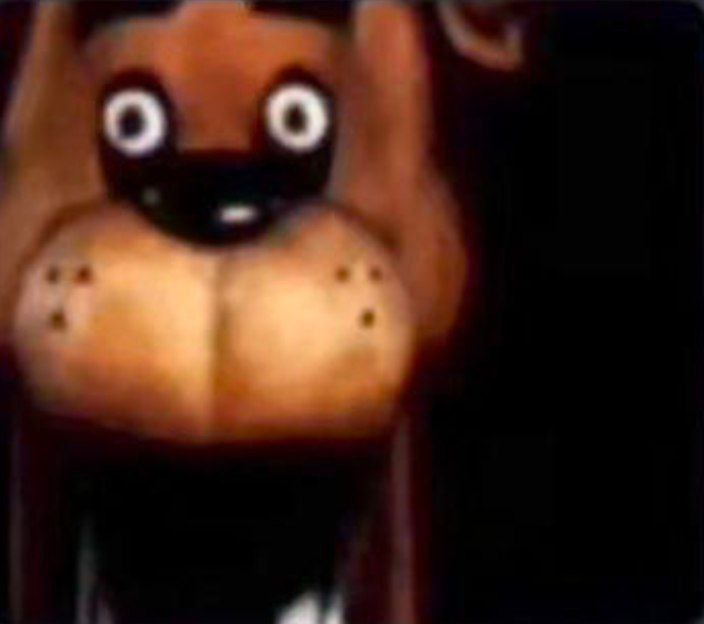